In [ ]:
%load_ext autoreload
%autoreload 2

import argparse
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import mplhep
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader
from tqdm import tqdm

from analysis.gravnet.model import (
    NeutrinoGravNetNodesFaser,
    NeutrinoGravNetNodesGraphFaser,
)
from analysis.utils.colors import TangoColors
from analysis.utils.datasets import CNNProjectionDataset
from analysis.utils.geometry import Geometry, get_rebinned_geometry
from analysis.utils.models import GraphClassifier, MuonHitNetClassifier
from analysis.utils.plot_utils import setup
from analysis.utils.torch_geometric_utils import (
    evaluate_gravnet_model,
    evaluate_gravnet_model_nodes,
    evaluate_pointnetpp_model,
)
from analysis.utils.torch_utils import (
    get_device,
    load_weights,
    show_model,
    train,
)
from analysis.utils.truth import TruthParticle, get_truth_particle
from analysis.utils.units import um
from analysis.utils.utils import (
    get_figures_path,
    get_npy_path,
    get_parquet_path,
    get_torch_path,
    get_weights_path,
)
from analysis.utils.validation_utils import (
    get_accuracy_dict,
    plot_confusion_matrix,
    plot_precision_recall_curve,
    plot_probabilities,
    plot_roc_curve,
    plot_training_metrics,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
def evaluate(
    model: nn.Module,
    test_loader: DataLoader,
    device: torch.device,
    use_faser: bool = False,
) -> tuple[list, list, list]:
    model.eval()
    all_targets, all_predictions, all_probabilities = [], [], []
    with torch.no_grad():
        for data in tqdm(test_loader, desc="Evaluating"):
            data = data.to(device)

            if data.x.size(0) == 0:
                continue

            if use_faser:
                out = model(data.x, data.pos, data.batch, data.x_faser)
            else:
                out = model(data.x, data.pos, data.batch)

            prob = torch.softmax(out, dim=1)
            pred = out.argmax(dim=1)

            all_targets.append(data.y.cpu().numpy())
            all_predictions.append(pred.cpu().numpy())
            all_probabilities.append(prob.cpu().numpy())

    return all_targets, all_predictions, all_probabilities

In [2]:
setup()

In [3]:
@dataclass
class HitType:
    idx: int
    label: str
    latex_name: str
    color: str = "black"


other_hit = HitType(0, "other", "Other", TangoColors.sky_blue)
e_hit = HitType(1, "e", r"$e^{\pm}$", TangoColors.scarlet_red)
mu_hit = HitType(2, "mu", r"$\mu^{\pm}$", TangoColors.chameleon)
# hits = [other_hit, other_e_hit, primary_e_hit, primary_mu_hit]
hits = [other_hit, e_hit, mu_hit]

In [4]:
@dataclass
class NuType:
    idx: int
    label: str
    latex_name: str


nun = NuType(0, "nun", "NC")
nue = NuType(1, "nue", r"CC $\nu_{e}$")
num = NuType(2, "num", r"CC $\nu_{\mu}$")
nus = [nun, nue, num]

# Main

In [9]:
model = "gravnet_nodes_faser"
# model = "gravnet_nodes_graph_faser"
weights_path = get_weights_path() / f"{model}/best_model.pt"
figures_path = get_figures_path() / model
figures_path.mkdir(parents=True, exist_ok=True)

In [10]:
# Test dataset
# data_path = get_torch_path() / "pointnetpp/test_dataset.pt"
# test_dataset = torch.load(data_path)
# test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, drop_last=True)

In [11]:
data_model = "pointnetpp_faser"
torch_path = get_torch_path()
nue_path = torch_path / f"10000/{data_model}"
num_path = torch_path / f"10001/{data_model}"
nun_path = torch_path / f"10003/{data_model}"

num_events = 10
nue_dataset = torch.load(nue_path / "nue.pt", weights_only=False)[:num_events]
nue_truth_df = pd.read_parquet(nue_path / "nue_truth.parq")[:num_events]
num_dataset = torch.load(num_path / "num.pt", weights_only=False)[:num_events]
num_truth_df = pd.read_parquet(num_path / "num_truth.parq")[:num_events]
nun_dataset = torch.load(nun_path / "nun.pt", weights_only=False)[:num_events]
nun_truth_df = pd.read_parquet(nun_path / "nun_truth.parq")[:num_events]
dataset = nue_dataset + num_dataset + nun_dataset
truth_df = pd.concat([nue_truth_df, num_truth_df, nun_truth_df], ignore_index=True)

In [13]:
device = get_device("cpu")

# model = NeutrinoGravNetNodesGraphFaser(
#     input_dim=dataset[0].x.shape[1],
#     faser_dim=dataset[0].x_faser.shape[0],
#     num_graph_classes=len(nus),
#     num_node_classes=len(hits),
# )
model = NeutrinoGravNetNodesFaser(
    input_dim=dataset[0].x.shape[1],
    num_node_classes=len(hits),
    faser_dim=dataset[0].x_faser.shape[0],
)
model = model.to(device)

load_weights(model, device=device, weights_path=weights_path)

Using device: cpu


In [27]:
# y_node_true, y_node_pred, y_node_prob, y_graph_true, y_graph_pred, y_graph_prob = (
#     evaluate_pointnetpp_model(
#         model=model,
#         test_loader=data_loader,
#         device=device,
#         use_faser=True,
#     )
# )

data_loader = DataLoader(dataset)
y_node_true, y_node_pred, y_node_prob = evaluate(
    model=model,
    test_loader=data_loader,
    device=device,
    use_faser=True,
    # model=model, test_loader=test_loader, device=device
)

Evaluating: 100%|██████████| 30/30 [00:04<00:00,  6.54it/s]


In [28]:
# y_node_true_flat = np.concatenate(y_node_true)
# y_node_pred_flat = np.concatenate(y_node_pred)
# y_node_prob_flat = np.concatenate(y_node_prob)

# y_graph_true_flat = np.concatenate(y_graph_true)
# y_graph_pred_flat = np.concatenate(y_graph_pred)
# y_graph_prob_flat = np.concatenate(y_graph_prob)

y_node_true_flat = np.concatenate(y_node_true)
y_node_pred_flat = np.concatenate(y_node_pred)
y_node_prob_flat = np.concatenate(y_node_prob)

In [29]:
acc_dict = get_accuracy_dict(
    y_true=y_node_true_flat,
    y_pred=y_node_pred_flat,
    class_names=[hit.label for hit in hits],
)
for label, acc in acc_dict.items():
    print(f"{label}: {acc * 100:.1f}%")

other: 70.6%
e: 78.8%
mu: 63.7%
average: 71.1%


In [ ]:
y_node_prob[idx][2]

array([[0.21202728, 0.7000548 , 0.08791786],
       [0.11047818, 0.82279086, 0.06673103],
       [0.07993732, 0.8411392 , 0.0789235 ],
       ...,
       [0.01411032, 0.00403974, 0.98184997],
       [0.01537867, 0.00375981, 0.9808615 ],
       [0.01482052, 0.00335564, 0.98182386]],
      shape=(11896, 3), dtype=float32)

In [42]:
hits

[HitType(idx=0, label='other', latex_name='Other', color='#3465a4'),
 HitType(idx=1, label='e', latex_name='$e^{\\pm}$', color='#cc0000'),
 HitType(idx=2, label='mu', latex_name='$\\mu^{\\pm}$', color='#73d216')]

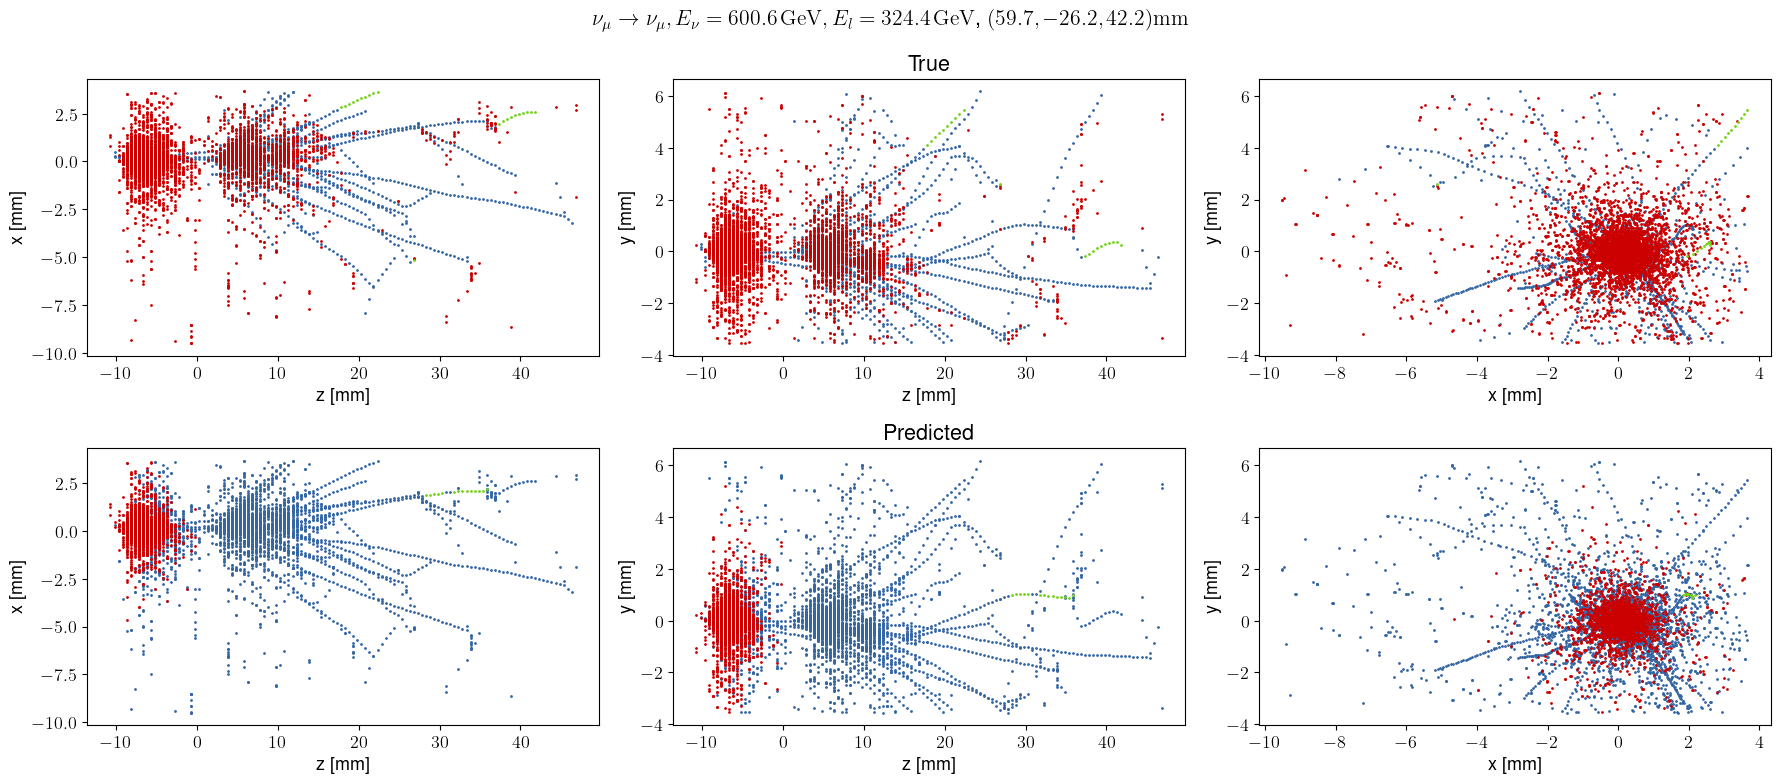

In [64]:
idx = 20
pos = dataset[idx].pos.numpy()
truth: TruthParticle = get_truth_particle(truth_df.iloc[idx])

fig, axs = plt.subplots(2, 3, figsize=(3 * 6, 2 * 4))
fig.suptitle(truth.get_latex_title())
for hit in hits:
    for i, (pred, title) in enumerate(
        zip([y_node_true[idx], y_node_pred[idx]], ["True", "Predicted"])
    ):
        hit_pos = pos[pred == hit.idx]
        axs[i][0].scatter(hit_pos[:, 2], hit_pos[:, 0], s=1, color=hit.color)
        axs[i][0].set_xlabel("z [mm]")
        axs[i][0].set_ylabel("x [mm]")

        axs[i][1].scatter(hit_pos[:, 2], hit_pos[:, 1], s=1, color=hit.color)
        axs[i][1].set_xlabel("z [mm]")
        axs[i][1].set_ylabel("y [mm]")

        axs[i][2].scatter(hit_pos[:, 0], hit_pos[:, 1], s=1, color=hit.color)
        axs[i][2].set_xlabel("x [mm]")
        axs[i][2].set_ylabel("y [mm]")

        axs[i][1].set_title(title)

plt.tight_layout()
plt.show()

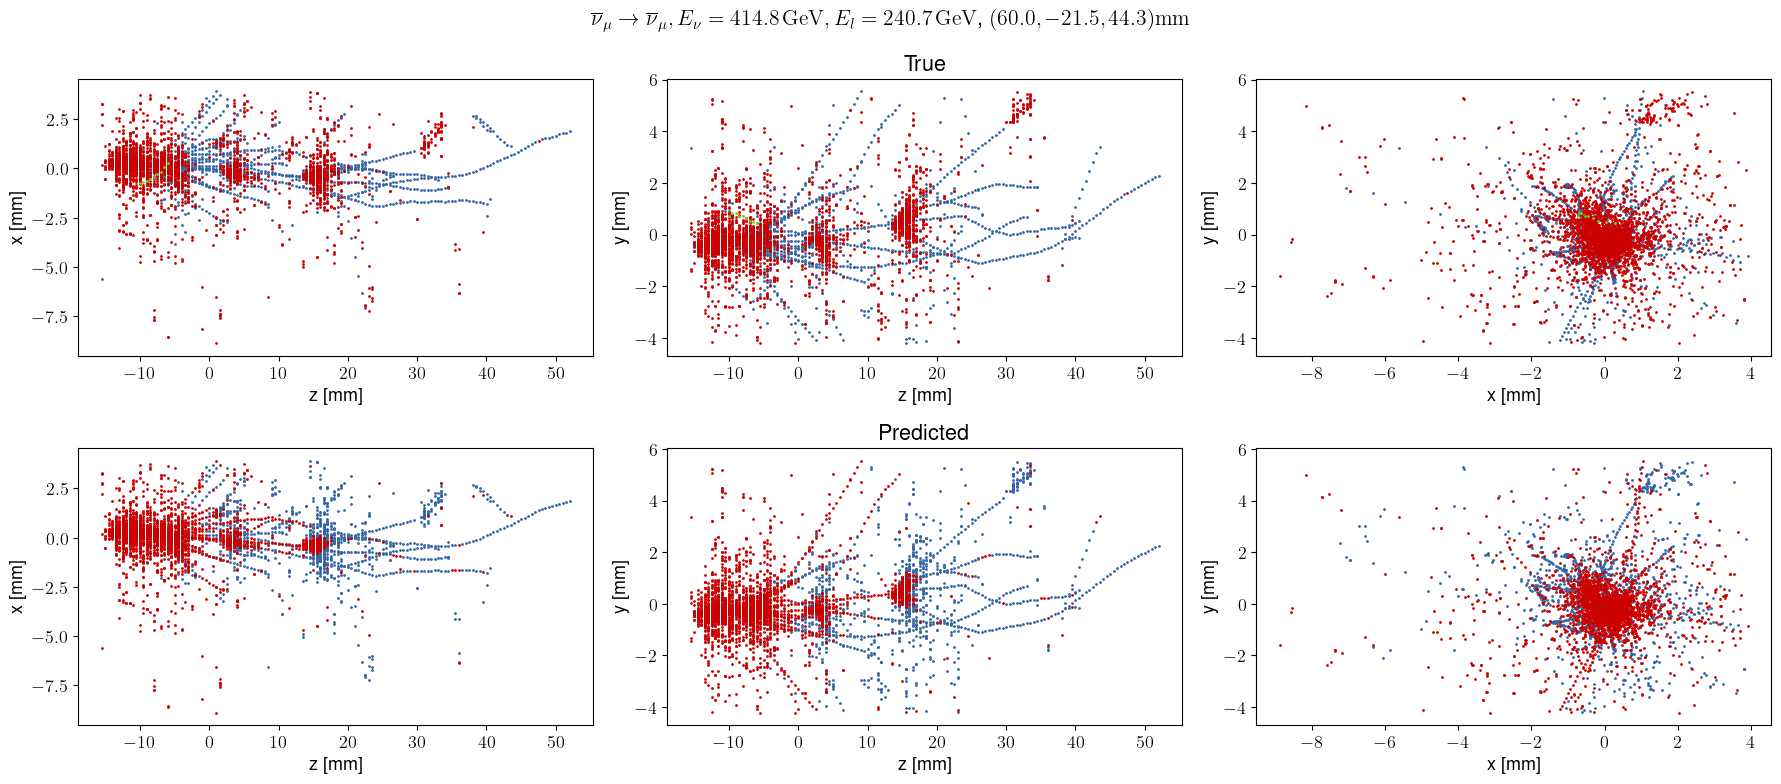

In [102]:
# idx = 25
idx = 26
pos = dataset[idx].pos.numpy()
truth: TruthParticle = get_truth_particle(truth_df.iloc[idx])
prob = y_node_prob[idx]

my_pred = np.ones(len(pos))
my_pred[prob[:, 0] > 0.65] = 0
my_pred[prob[:, 2] > 0.9] = 2

fig, axs = plt.subplots(2, 3, figsize=(3 * 6, 2 * 4))
fig.suptitle(truth.get_latex_title())
i = 1
for hit in hits:
    for i, (pred, title) in enumerate(
        zip([y_node_true[idx], my_pred], ["True", "Predicted"])
    ):
        hit_pos = pos[pred == hit.idx]
        axs[i][0].scatter(hit_pos[:, 2], hit_pos[:, 0], s=1, color=hit.color)
        axs[i][0].set_xlabel("z [mm]")
        axs[i][0].set_ylabel("x [mm]")

        axs[i][1].scatter(hit_pos[:, 2], hit_pos[:, 1], s=1, color=hit.color)
        axs[i][1].set_xlabel("z [mm]")
        axs[i][1].set_ylabel("y [mm]")

        axs[i][2].scatter(hit_pos[:, 0], hit_pos[:, 1], s=1, color=hit.color)
        axs[i][2].set_xlabel("x [mm]")
        axs[i][2].set_ylabel("y [mm]")

        axs[i][1].set_title(title)

plt.tight_layout()
plt.show()

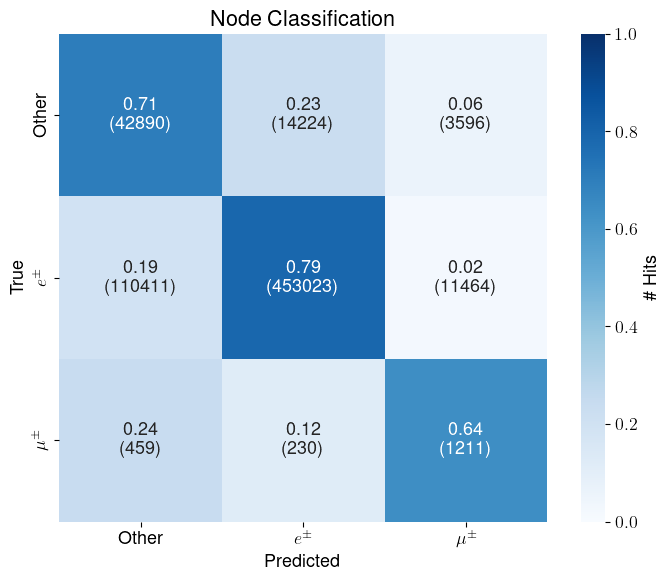

In [37]:
plot_confusion_matrix(
    y_node_true_flat,
    y_node_pred_flat,
    normalize=True,
    class_names=[hit.latex_name for hit in hits],
    cbar_label=r"\# Hits",
    title="Node Classification",
)

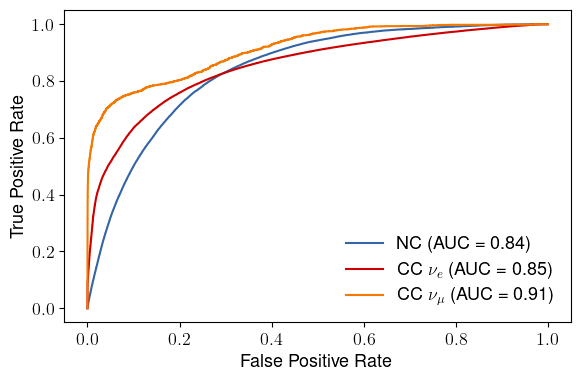

In [39]:
plot_roc_curve(
    y_true=y_node_true_flat,
    y_prob=y_node_prob_flat,
    class_names=[nu.latex_name for nu in nus],
    figure_path=figures_path / "roc_curve.png",
)

60710.0
60710.0
60710.0


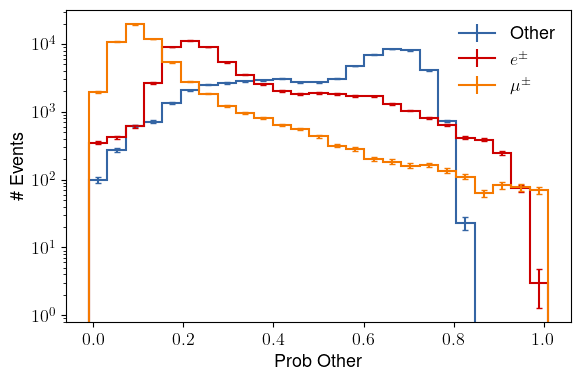

574898.0
574898.0
574898.0


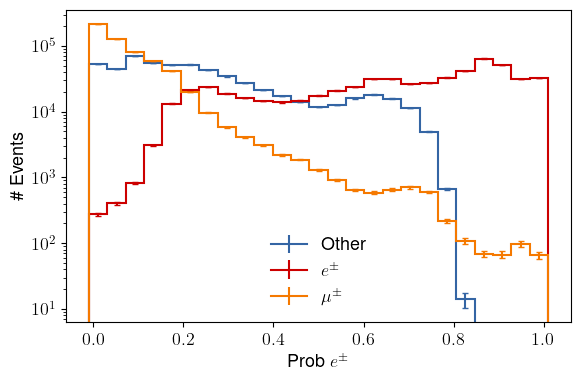

1900.0
1900.0
1900.0


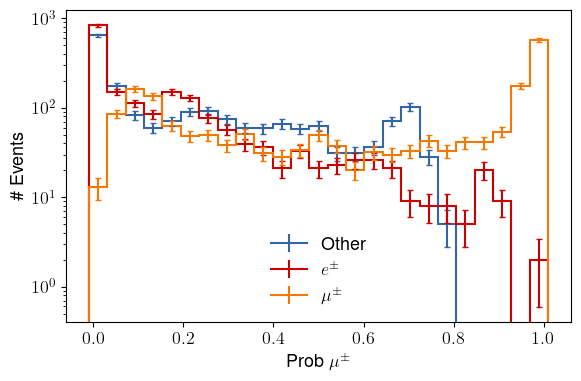

In [40]:
plot_probabilities(
    y_true=y_node_true_flat,
    y_prob=y_node_prob_flat,
    class_names=[hit.latex_name for hit in hits],
    yscale="log",
    num_bins=25,
)

1813.0
1813.0
1813.0


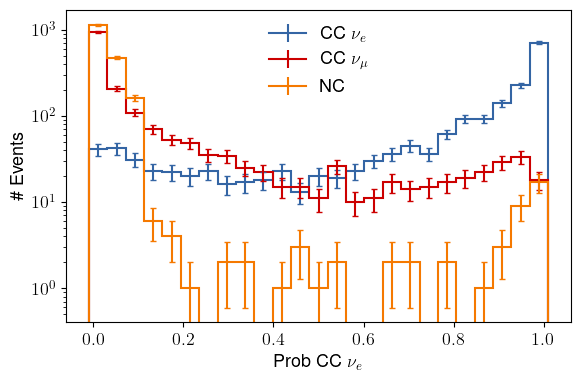

1927.0
1927.0
1927.0


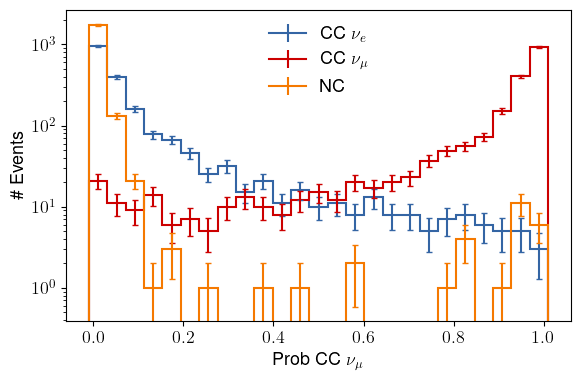

1945.0
1945.0
1945.0


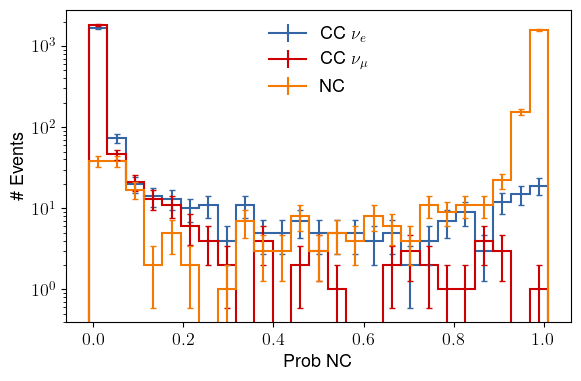

In [35]:
plot_probabilities(
    y_true=y_graph_true_flat,
    y_prob=y_graph_prob_flat,
    class_names=[nu.latex_name for nu in nus],
    yscale="log",
    num_bins=25,
)